In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# this was running on 4 utah m400 machines (8 cores each, 32 cores total, no smt)

In [3]:
df1 = pd.read_csv("data/benchmark_log.csv").set_index(["test_type", "n", "num_cpus"])
df2 = pd.read_csv("data/benchmark_log2.csv").set_index(["test_type", "n", "num_cpus"])
df = pd.concat([df1, df2])
df["admm_time"] = df["solve"] - df["_get_grouped_objectives"] - df["get_subproblems"] - df["populate_vars_with_solution"]
df["admm_time_per_iter"] = df["admm_time"] / df["num_iterations"]
df["group_time"] = df["_get_grouped_objectives"]
df["misc_time"] = df["__init__"] + df["get_subproblems"] + df["populate_vars_with_solution"]
df = df.rename({"solve": "total_time"}, axis=1)
df

,,,num_iterations,__init__,_get_grouped_objectives,get_subproblems,populate_vars_with_solution,total_time,admm_time,admm_time_per_iter,group_time,misc_time
test_type,n,num_cpus,,,,,,,,,,
sum,100,1,4,0.7919,9.1884,1.2988,1.3027,40.1739,28.3840,7.096000,9.1884,3.3934
weighted,30,1,31,0.1429,8.0203,0.1957,0.1301,34.1195,25.7734,0.831400,8.0203,0.4687
log,10,1,7,0.0432,8.2551,0.0950,0.0283,14.5797,6.2013,0.885900,8.2551,0.1665
sum,100,2,4,0.9513,8.8755,1.3446,0.8009,27.4958,16.4748,4.118700,8.8755,3.0968
weighted,30,2,28,0.3239,8.6687,0.2599,0.0965,25.0177,15.9926,0.571164,8.6687,0.6803
...,...,...,...,...,...,...,...,...,...,...,...,...
log,220,8,10,3.7716,333.2335,11.2132,2.9124,592.0481,244.6890,24.468900,333.2335,17.8972
weighted,660,16,4,28.9464,79.3001,62.0203,24.7886,264.2878,98.1788,24.544700,79.3001,115.7553
log,220,16,10,3.5125,333.1801,11.6612,2.5532,490.1179,142.7234,14.272340,333.1801,17.7269


In [4]:
TEST_TYPES = ["sum", "weighted", "log"]
SHAREY = False  # set True to synchronize y-axes across subplots

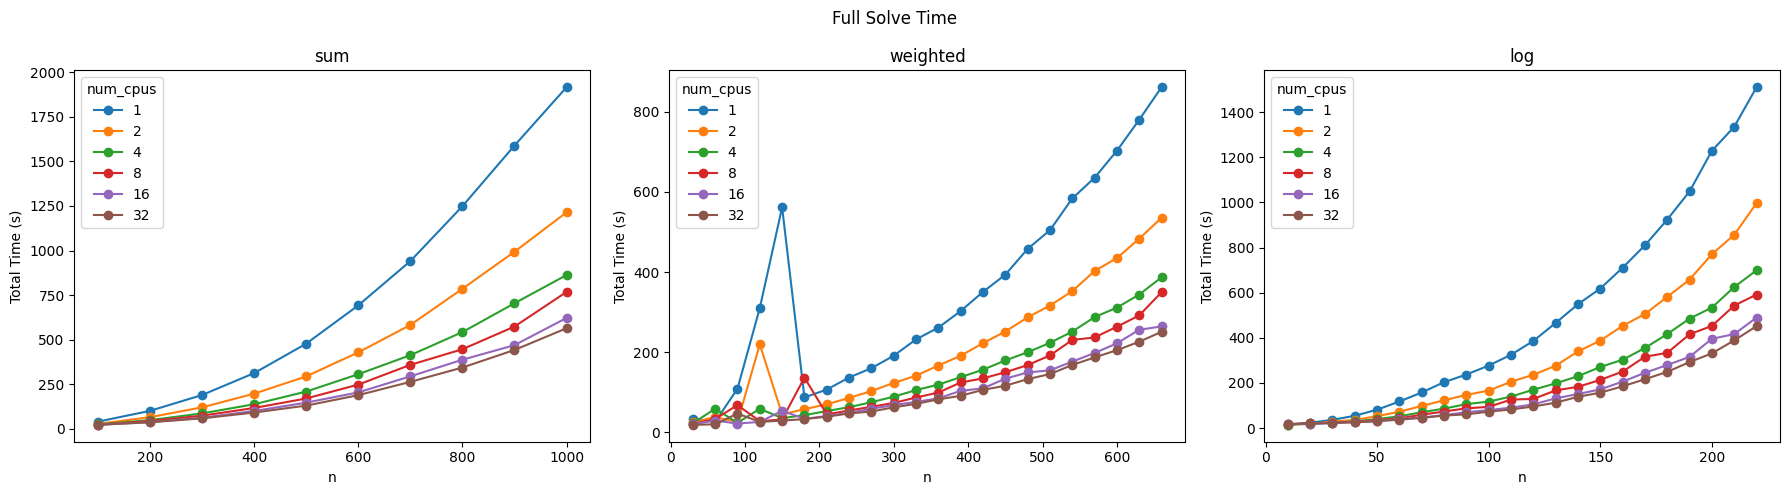

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["total_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Total Time (s)")
    ax.set_title(test_type)
fig.suptitle("Full Solve Time")
fig.tight_layout()
plt.show()

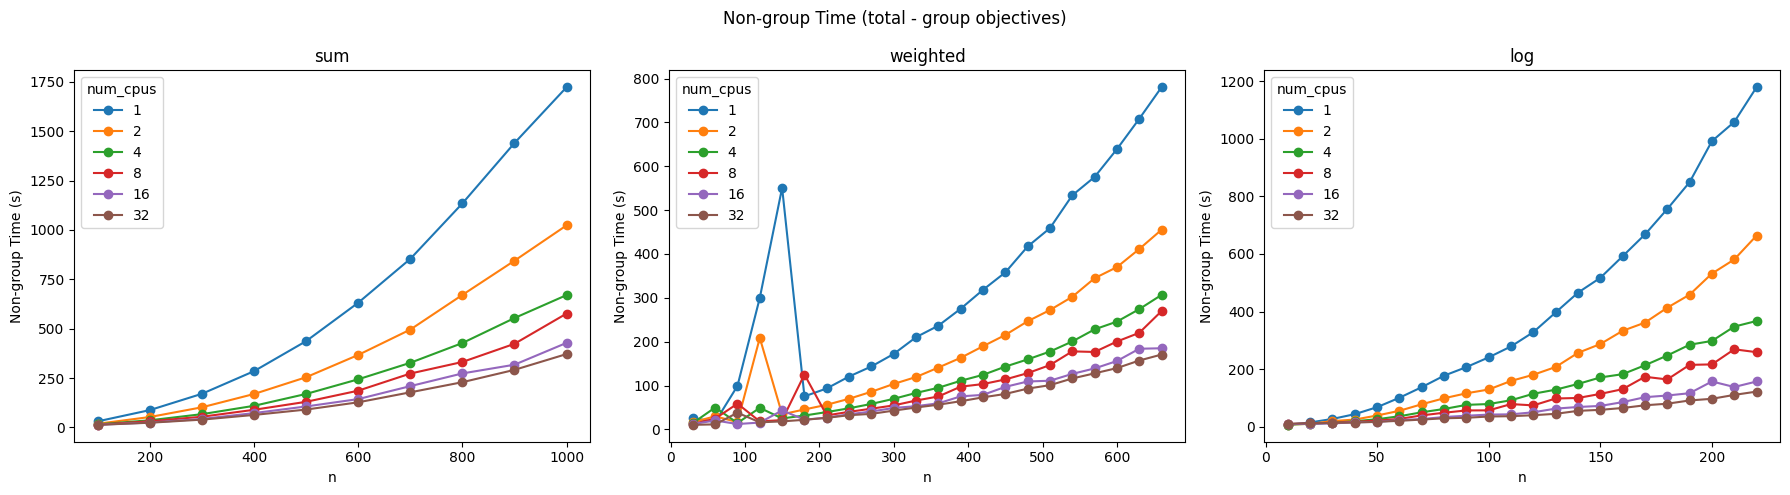

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["total_time"] - df_t["group_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Non-group Time (s)")
    ax.set_title(test_type)
fig.suptitle("Non-group Time (total - group objectives)")
fig.tight_layout()
plt.show()

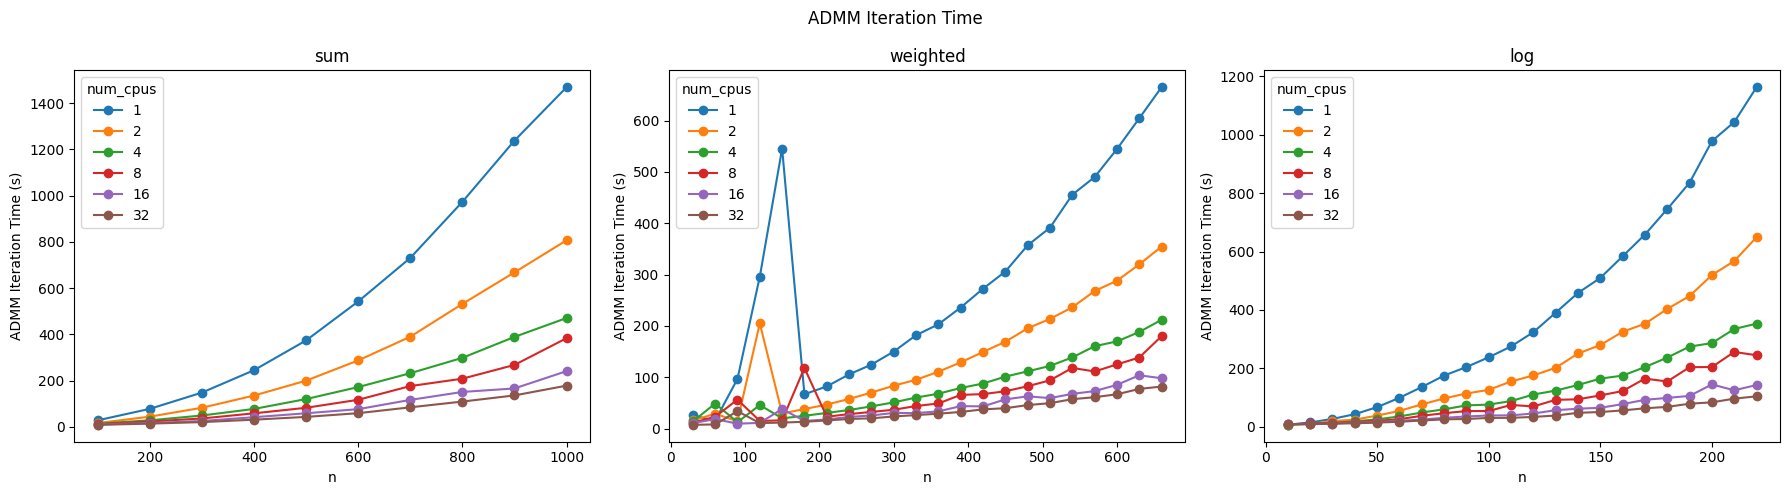

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time")
fig.tight_layout()
plt.show()

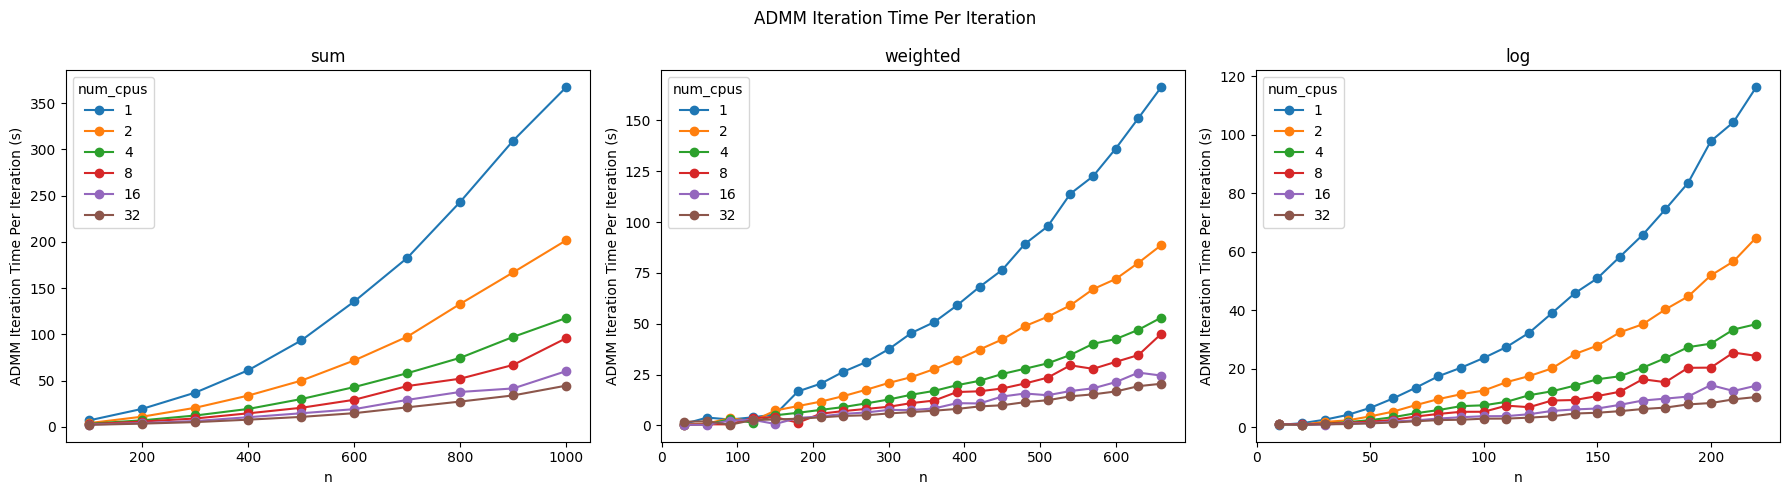

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time_per_iter"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time_per_iter"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time Per Iteration (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time Per Iteration")
fig.tight_layout()
plt.show()

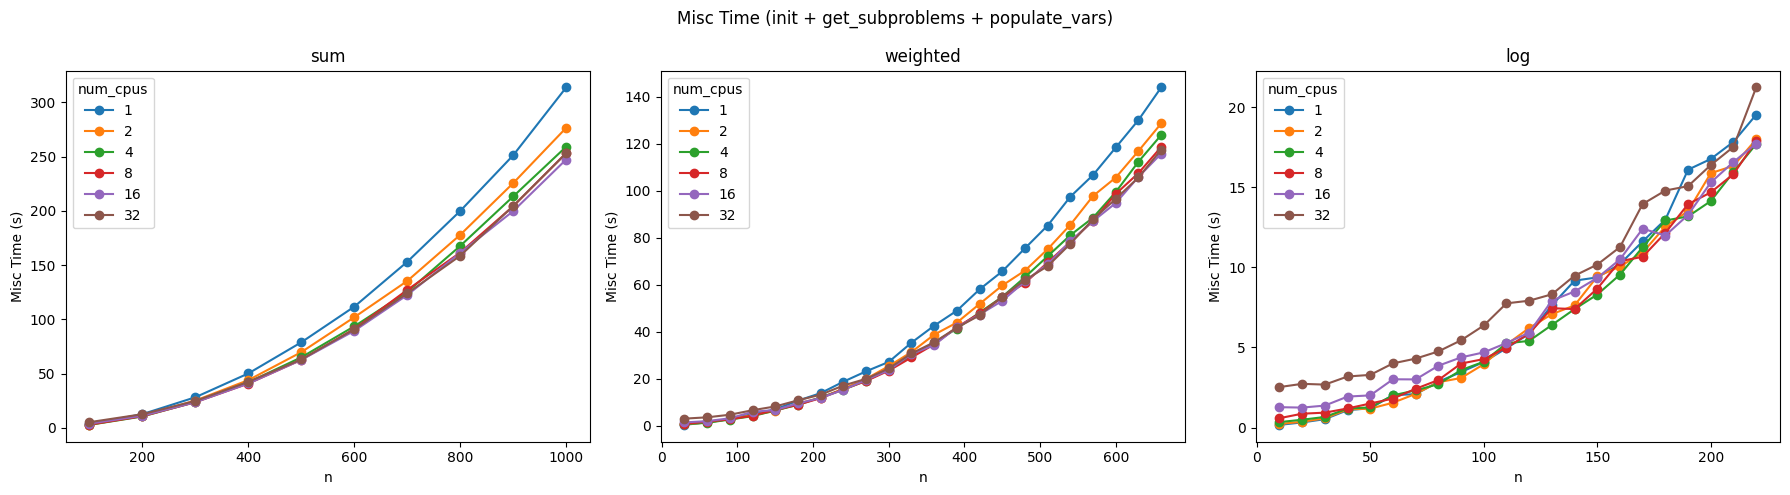

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["misc_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["misc_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Misc Time (s)")
    ax.set_title(test_type)
fig.suptitle("Misc Time (init + get_subproblems + populate_vars)")
fig.tight_layout()
plt.show()

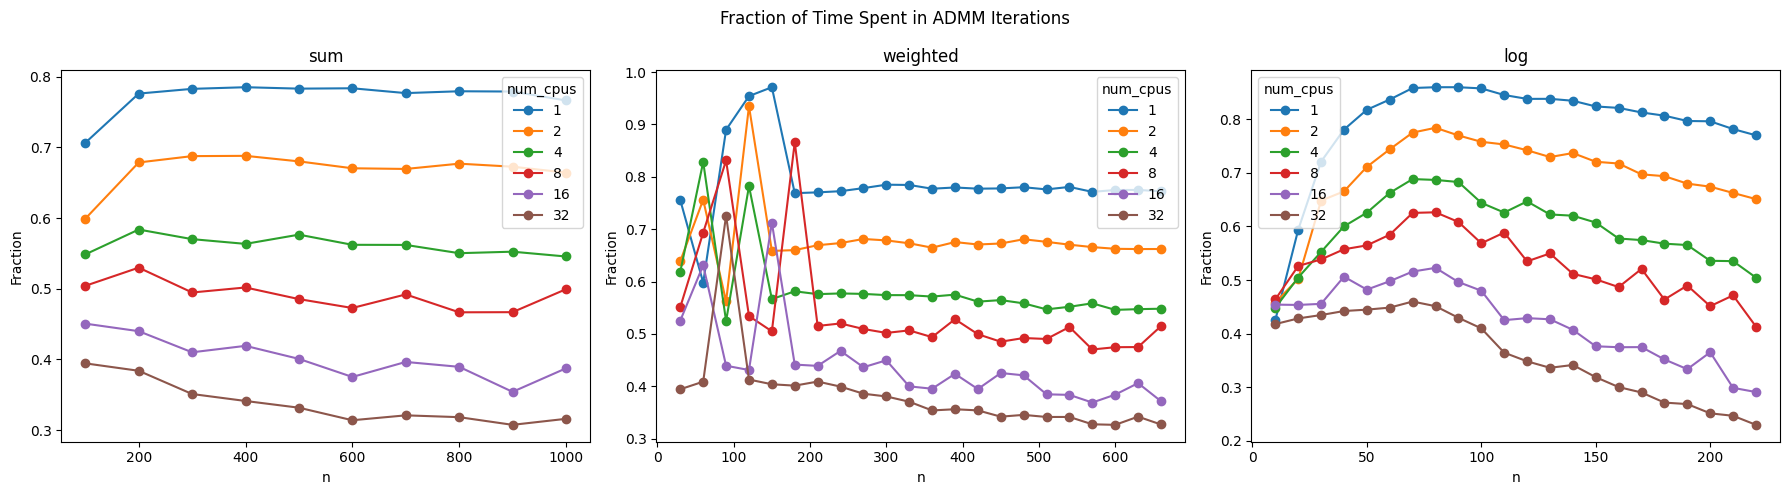

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["admm_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Fraction")
    ax.set_title(test_type)
fig.suptitle("Fraction of Time Spent in ADMM Iterations")
fig.tight_layout()
plt.show()

In [11]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
# for ax, test_type in zip(axes, TEST_TYPES):
#     df_t = df.loc[test_type].unstack("num_cpus")
#     (df_t["group_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
#     ax.legend(df_t["group_time"].columns, title="num_cpus")
#     ax.set_xlabel("n")
#     ax.set_ylabel("Fraction")
#     ax.set_title(test_type)
# fig.suptitle("Fraction of Time Spent Grouping Objectives")
# fig.tight_layout()
# plt.show()

In [12]:
group_objectives_df = pd.read_csv("data/group_objectives_log.csv").set_index(["test_type", "num_cpus", "strategy", "n"]).rename({"_get_grouped_objectives": "group_time"}, axis=1)
group_objectives_df

num_iterations  __init__  group_time
test_type num_cpus strategy n                                        
sum       1        PACK     50                0    0.3053      2.9776
weighted  1        PACK     30                0    0.3151      0.6239
log       1        PACK     10                0    0.0496      2.2901
sum       2        PACK     50                0    0.2932      3.3636
weighted  2        PACK     30                0    0.1489      2.4698
...                                         ...       ...         ...
          16       SPREAD   450               0   12.2579     26.3710
log       16       SPREAD   150               0    1.6115     92.0494
sum       32       SPREAD   750               0   35.1517    100.1723
weighted  32       SPREAD   450               0   12.9221     35.0515
log       32       SPREAD   150               0    1.9489     83.6920

[405 rows x 3 columns]

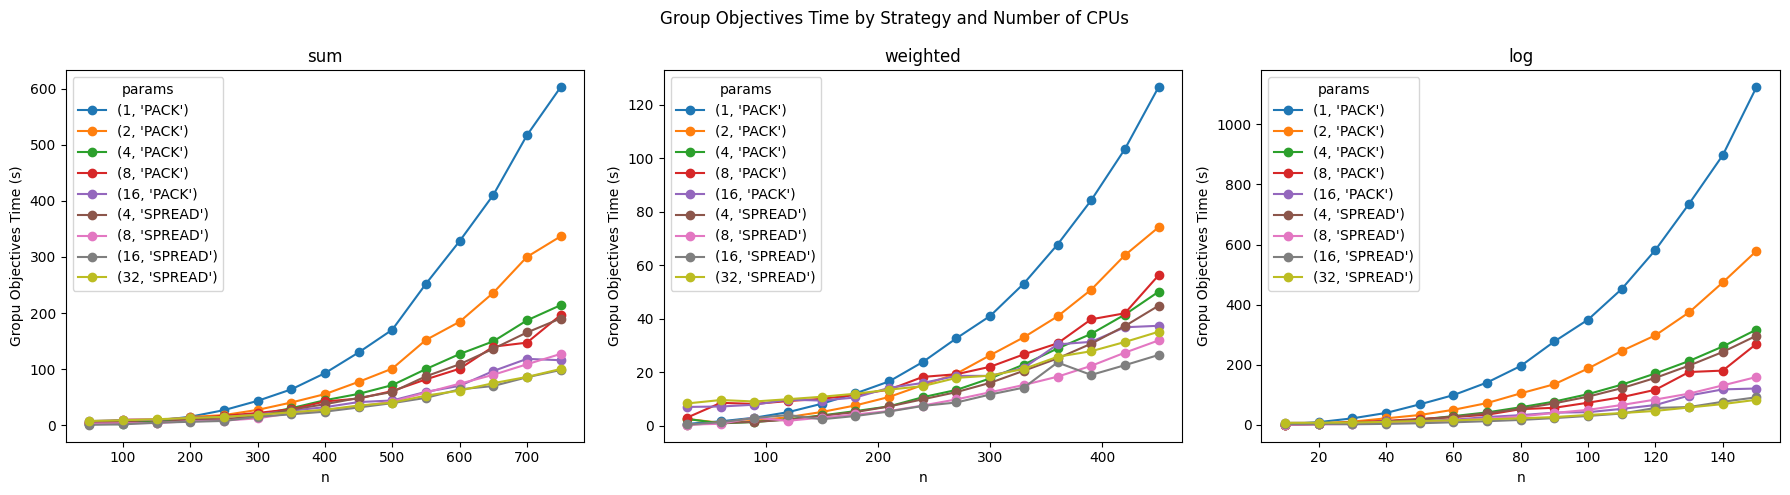

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = group_objectives_df.loc[test_type].unstack(["num_cpus", "strategy"])
    df_t["group_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["group_time"].columns, title="params")
    ax.set_xlabel("n")
    ax.set_ylabel("Gropu Objectives Time (s)")
    ax.set_title(test_type)
fig.suptitle("Group Objectives Time by Strategy and Number of CPUs")
fig.tight_layout()
plt.show()

In [15]:
group_objectives_df2 = pd.read_csv("data/singlethread_group_time.csv").set_index(["test_type", "num_cpus", "n"]).rename({"_get_grouped_objectives": "group_time"}, axis=1)
group_objectives_df2

,,,num_iterations,__init__,group_time,result
test_type,num_cpus,n,,,,
sum,1,50,0,0.0938,0.0304,0
weighted,1,50,0,0.1106,0.0324,0
log,1,50,0,0.1307,0.0268,0
sum,1,100,0,0.2543,0.1506,0
weighted,1,100,0,0.2511,0.1563,0
log,1,100,0,0.2516,0.1440,0
sum,1,150,0,0.4884,0.2724,0
weighted,1,150,0,0.5285,0.2862,0
log,1,150,0,0.5344,0.2674,0


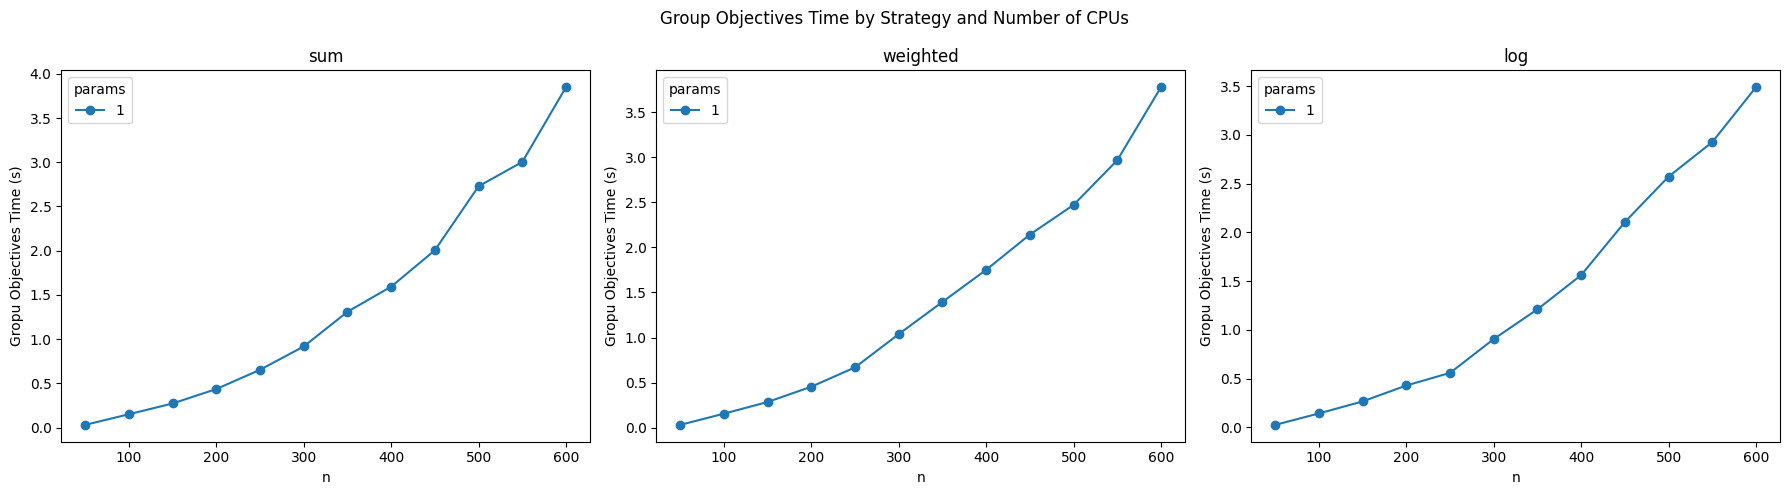

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = group_objectives_df2.loc[test_type].unstack(["num_cpus"])
    df_t["group_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["group_time"].columns, title="params")
    ax.set_xlabel("n")
    ax.set_ylabel("Gropu Objectives Time (s)")
    ax.set_title(test_type)
fig.suptitle("Group Objectives Time (1 core, tree)")
fig.tight_layout()
plt.show()